# Aufgabe 2 - Tiefe Einblicke ins Institut

Den Code immer nachvollziehbar kommentieren! Bitte beachtet, dass das Notebook von Anfang bis Ende ohne Fehler durchlaufen muss und dass die requirements.txt Datei aktualisiert wird. 

In [163]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Teilaufgabe a): Trainings-und Testdatenset

In [164]:
rooms = ['Flur', 'Labor', 'Professorenbuero', 'Teekueche']
training_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(1,21)]  # ["./pfad/zu/bildA.png","./pfad/zu/bildB.png",...] -- 20 Bilder je Klasse
test_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(21,26)]  # ["./pfad/zu/bildC.png","./pfad/zu/bildD.png",...] -- 5 Bilder je Klasse

## Teilaufgabe b): Verteilung RGB

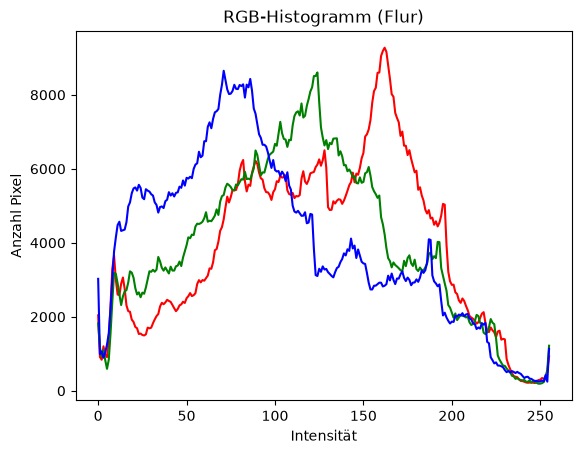

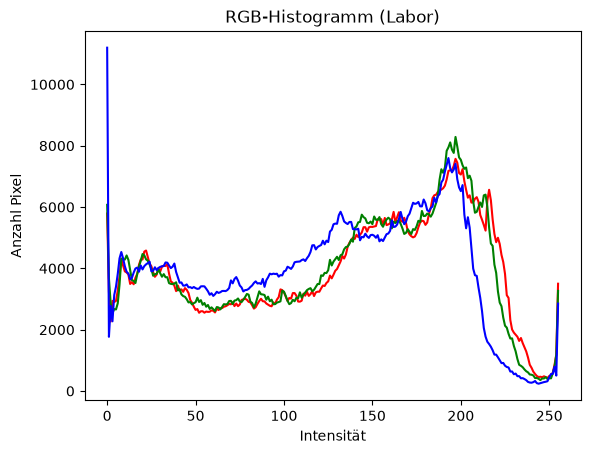

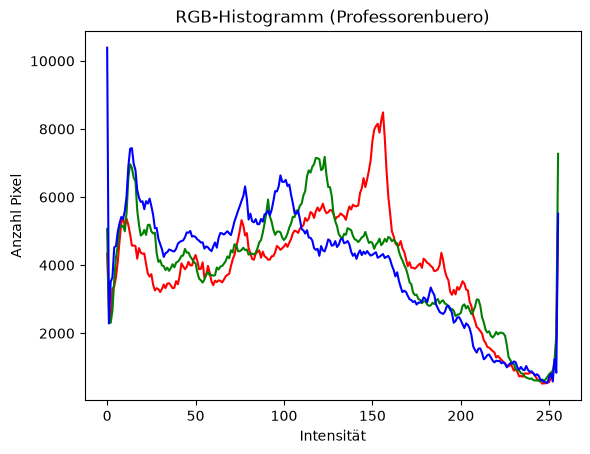

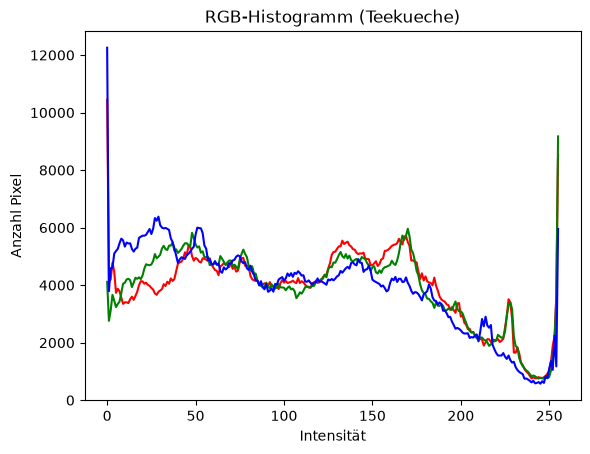

In [165]:
for room in rooms:
    r_ges = []
    g_ges = []
    b_ges = []
    for path in training_path_list:
        if path.split('/')[1] != room: continue
        img = plt.imread(path)
        r = img[:, :, 0]
        g = img[:, :, 1]
        b = img[:, :, 2]
        for k in range(len(r)):
            r_ges.append(r[k]) # zählen Werte
        for k in range(len(g)):
            g_ges.append(g[k])
        for k in range(len(b)):
            b_ges.append(b[k])
    
    bins = 256
    hist_r, _ = np.histogram(r_ges, bins=bins, range=(0, 256)) # erstellen Histogramm
    hist_g, _    = np.histogram(g_ges, bins=bins, range=(0, 256))
    hist_b, _    = np.histogram(b_ges, bins=bins, range=(0, 256))

    plt.plot(hist_r, color="red") # Plotten Histogramm
    plt.plot(hist_g, color="green")
    plt.plot(hist_b, color="blue")
    plt.xlabel("Intensität")
    plt.ylabel("Anzahl Pixel")
    plt.title(f"RGB-Histogramm ({room})")
    plt.show()

## Teilaufgabe c): Training und Test mit Random Forest 

In [166]:
def extract_features(path): # Histogramm pro Bild
    img = np.array(Image.open(path).convert("RGB"))
    bins = 64 # ... mit 64 Features
    hist_r, _ = np.histogram(img[:,:,0], bins=bins, range=(0,256))
    hist_g, _ = np.histogram(img[:,:,1], bins=bins, range=(0,256))
    hist_b, _ = np.histogram(img[:,:,2], bins=bins, range=(0,256))

    return np.concatenate([hist_r, hist_g, hist_b])


X_train = np.array([extract_features(p) for p in training_path_list]) # Histogramme der Trainingsdaten
X_test  = np.array([extract_features(p) for p in test_path_list]) # Histogramme der Testdaten

y_train = [Path(p).parent.name for p in training_path_list] # Klassen der jeweiligen Trainigsdaten
y_test = [Path(p).parent.name for p in test_path_list] # Klassen der jeweiligen Testdaten

In [167]:
clf = RandomForestClassifier( # Bauen Random-Forest
    n_estimators=30, # Anzahl der Bäume
    random_state=42
)

clf.fit(X_train, y_train) # Bauen der Bäume

y_pred = clf.predict(X_test) # Testen des Classifiers

In [168]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.65
Precision: 0.7125
Recall   : 0.65
F1       : 0.6580128205128204


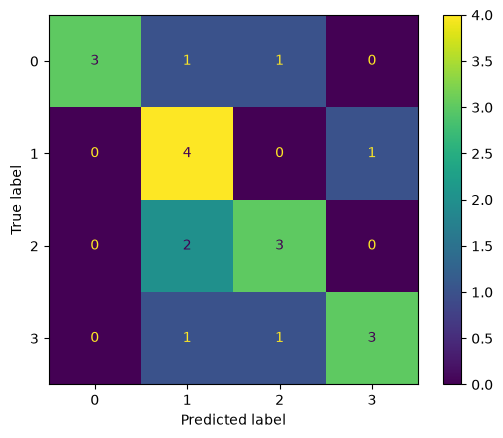

In [169]:
# Bauen und Plotten der Confusion-Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe d): Hyperparameteroptimierung

In [180]:
# X_train, y_train, X_test, y_test stammen aus Aufgabe c

param_grid = {
    'n_estimators': [100, 1000, 2000], # Varianten zum Testen (Anzahl der Bäume)
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV( # Cross Validation
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Beste Parameter:")
print(grid.best_params_)

Beste Parameter:
{'n_estimators': 1000}


In [181]:
best_rf = grid.best_estimator_ # Classifier des Forests mit den besten Parametern

best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

In [182]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.7
Precision: 0.7166666666666666
Recall   : 0.7
F1       : 0.704040404040404


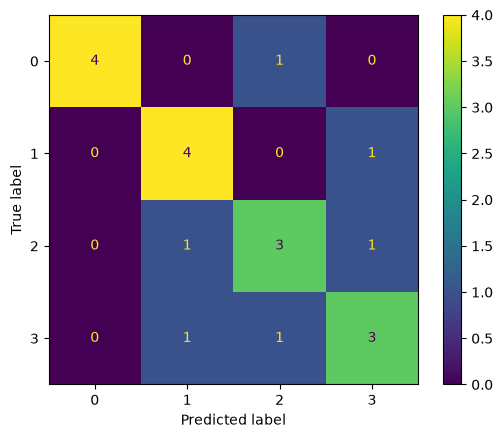

In [183]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe e): Dimensionalitätsreduktion

In [174]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [175]:
pca = PCA(n_components=0.95) # Hauptkomponentenanalyse

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [176]:
param_grid = {
    'n_estimators': [100, 1000, 2000]
}

rf = RandomForestClassifier(random_state=42)

grid_pca = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_pca.fit(X_train_pca, y_train)

print("Beste Parameter mit PCA:")
print(grid_pca.best_params_)

Beste Parameter mit PCA:
{'n_estimators': 1000}


In [177]:
best_rf_pca = RandomForestClassifier(
    n_estimators=grid_pca.best_params_['n_estimators'],
    random_state=42
)

best_rf_pca.fit(X_train_pca, y_train)

y_pred_pca = best_rf_pca.predict(X_test_pca)

In [178]:
print("Accuracy :", accuracy_score(y_test, y_pred_pca))
print("Precision:", precision_score(y_test, y_pred_pca, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_pca, average="weighted"))
print("F1       :", f1_score(y_test, y_pred_pca, average="weighted"))

Accuracy : 0.7
Precision: 0.7035714285714285
Recall   : 0.7
F1       : 0.6916666666666668


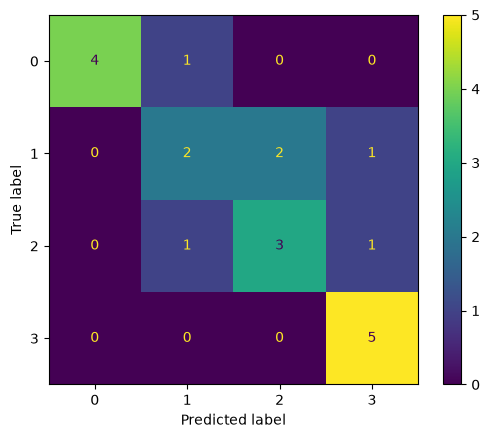

In [179]:
cm = confusion_matrix(y_test, y_pred_pca)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

### Vergleich

Der n-Estimator der Hyperparameteroptimierung hat sich bei der Dimensionsreduktion nicht geändert.
Die Accuracy und der Recall haben sich nicht geändert.
Die Precision hat sich von 0.72 auf 0.70 verschlechtert.
Dadurch hat sich F1-Score von 0.70 auf 0.69 verschlechtert.